# Assignment 3 - 02477 Bayesian Machine Learning

In [98]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
import seaborn as snb

snb.set_style('darkgrid')
snb.set(font_scale=1.25)

In [99]:
# Load data
data = jnp.load('./data_assignment3.npz')
x, y = data['x'], data['t']
print(x.shape)
print(y.shape)

(200,)
(200,)


In [100]:
xt = jnp.vstack((x, jnp.ones(200,))).T
print(xt.shape)

(200, 2)


> Task 1.1: Marginalize out each $z_n$ from the joint model in equation (7)

$$
K = \mathcal{N}(v|0,\tau^2I)\mathcal{N}(w_0|0,\tau^2I)\mathcal{N}(w_1|0,\tau^2I)\mathcal{N}_{+}(\sigma_0|0,1)\mathcal{N}_{+}(\sigma_1|0,1)\mathcal{N}_{+}(\tau|0,1)
$$

$$
p(y,z,v,w_0,w_1,\sigma_0,\sigma_1) = \left[\prod_{n=1}^{N}\mathcal{N}(y_n|w_{z_n}^Tx_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n))\right]\cdot K
$$

$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = \sum_{z_1\in{0,1}}\sum_{z_2\in{0,1}}...\sum_{z_N\in{0,1}}p(y,z,v,w_0,w_1,\sigma_0,\sigma_1)
$$

$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = \sum_{z_1\in{0,1}}\sum_{z_2\in{0,1}}...\sum_{z_N\in{0,1}}\left[\prod_{n=1}^{N}\mathcal{N}(y_n|w_{z_n}^T x_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n))\right]\cdot K
$$

$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = K \cdot \sum_{z_1\in{0,1}}\sum_{z_2\in{0,1}}...\sum_{z_N\in{0,1}}\left[\prod_{n=1}^{N}\mathcal{N}(y_n|w_{z_n}^T x_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n))\right]
$$


$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = K\cdot \left[\prod_{n=1}^{N}\sum_{z_n\in{0,1}}\mathcal{N}(y_n|w_{z_n}^T x_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n))\right]
$$

For each value of n:
$$
\sum_{z_n\in{0,1}}\mathcal{N}(y_n|w_{z_n}^T x_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n)) = (1-\sigma(v^Tx_n))\mathcal{N}(y_n|w_0^T x_n, \sigma_0^2) + \sigma(v^Tx_n)\mathcal{N}(y_n|w_1^T x_n, \sigma_1^2)
$$

Then we arrive at:
$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = \left[\prod_{n=1}^{N}\left((1-\sigma(v^Tx_n))\mathcal{N}(y_n|w_0^T x_n, \sigma_0^2) + \sigma(v^Tx_n)\mathcal{N}(y_n|w_1^T x_n, \sigma_1^2)\right)\right]\cdot K
$$



> Task 1.2: Implement a Python function to evaluate the marginalized log joint distribution

In [110]:
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v)
npdf = lambda x, m, v: jnp.exp(log_npdf(x, m, v))
log_half_npdf = lambda x, m, v: jnp.log(2) -0.5*(x-m)**2/(v) - 0.5*jnp.log(2*jnp.pi*v)
sigmoid = lambda x: 1./(1 + jnp.exp(-x))


def log_joint(theta):

    w0 = theta[:2]
    w1 = theta[2:4]
    v = theta[4:6]
    # tau = jnp.exp(theta[6])
    # sig02 = jnp.exp(theta[7])
    # sig12 = jnp.exp(theta[8])
    tau = theta[6]
    sig02 = theta[7]
    sig12 = theta[8]
    
    sig0 = jnp.sqrt(sig02)
    sig1 = jnp.sqrt(sig12)
    # w0, w1, v are vectors
    
    sigs = sigmoid(v@xt.T)

    # We need to sample yn
    nw0 = jnp.sum(log_npdf(w0, 0, tau**2))
    nw1 = jnp.sum(log_npdf(w1, 0, tau**2))
    nv = jnp.sum(log_npdf(v, 0, tau**2))

    ntau = log_half_npdf(tau, 0, 1)
    nsig0 = log_half_npdf(sig0, 0, 1)
    nsig1 = log_half_npdf(sig1, 0, 1)

    likelihood = jnp.sum(jnp.log((1-sigs)*npdf(y, w0@xt.T, sig02) + sigs*npdf(y,w1@xt.T,sig12)))

    return likelihood + nw0 + nw1 + nv + ntau + nsig0 + nsig1


> Task 1.3: Run a Metropolis-Hasting sampler to infer all parameters. Explain the settings you used (number of iterations, proposal distribution etc.)

In [15]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau * random.normal(key_proposal,shape=(num_params, ))

        log_p_theta_star = log_target(theta_star)

        log_r = log_p_theta_star - log_p_theta

        A_k = jnp.minimum(1, jnp.exp(log_r))

        if random.uniform(key_accept) < A_k:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)         
        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas

In [71]:
# Run longer MCMC with better init
theta_init = jnp.array([0.5, 0.,    # w0 (positive intercept, small slope)
                        -0.5, 0.,   # w1 (negative intercept)
                        0., 0.,    # v (neutral gating)
                        2.,        # tau
                        0.2,       # sig02
                        0.2])      # sig12

num_iter = 50000  # More iterations
num_params = len(theta_init)


thetas = metropolis(log_joint, num_params, 0.4, num_iter=num_iter, theta_init=theta_init)

Acceptance ratio: 0.02


Text(0.5, 0, 'Iterations')

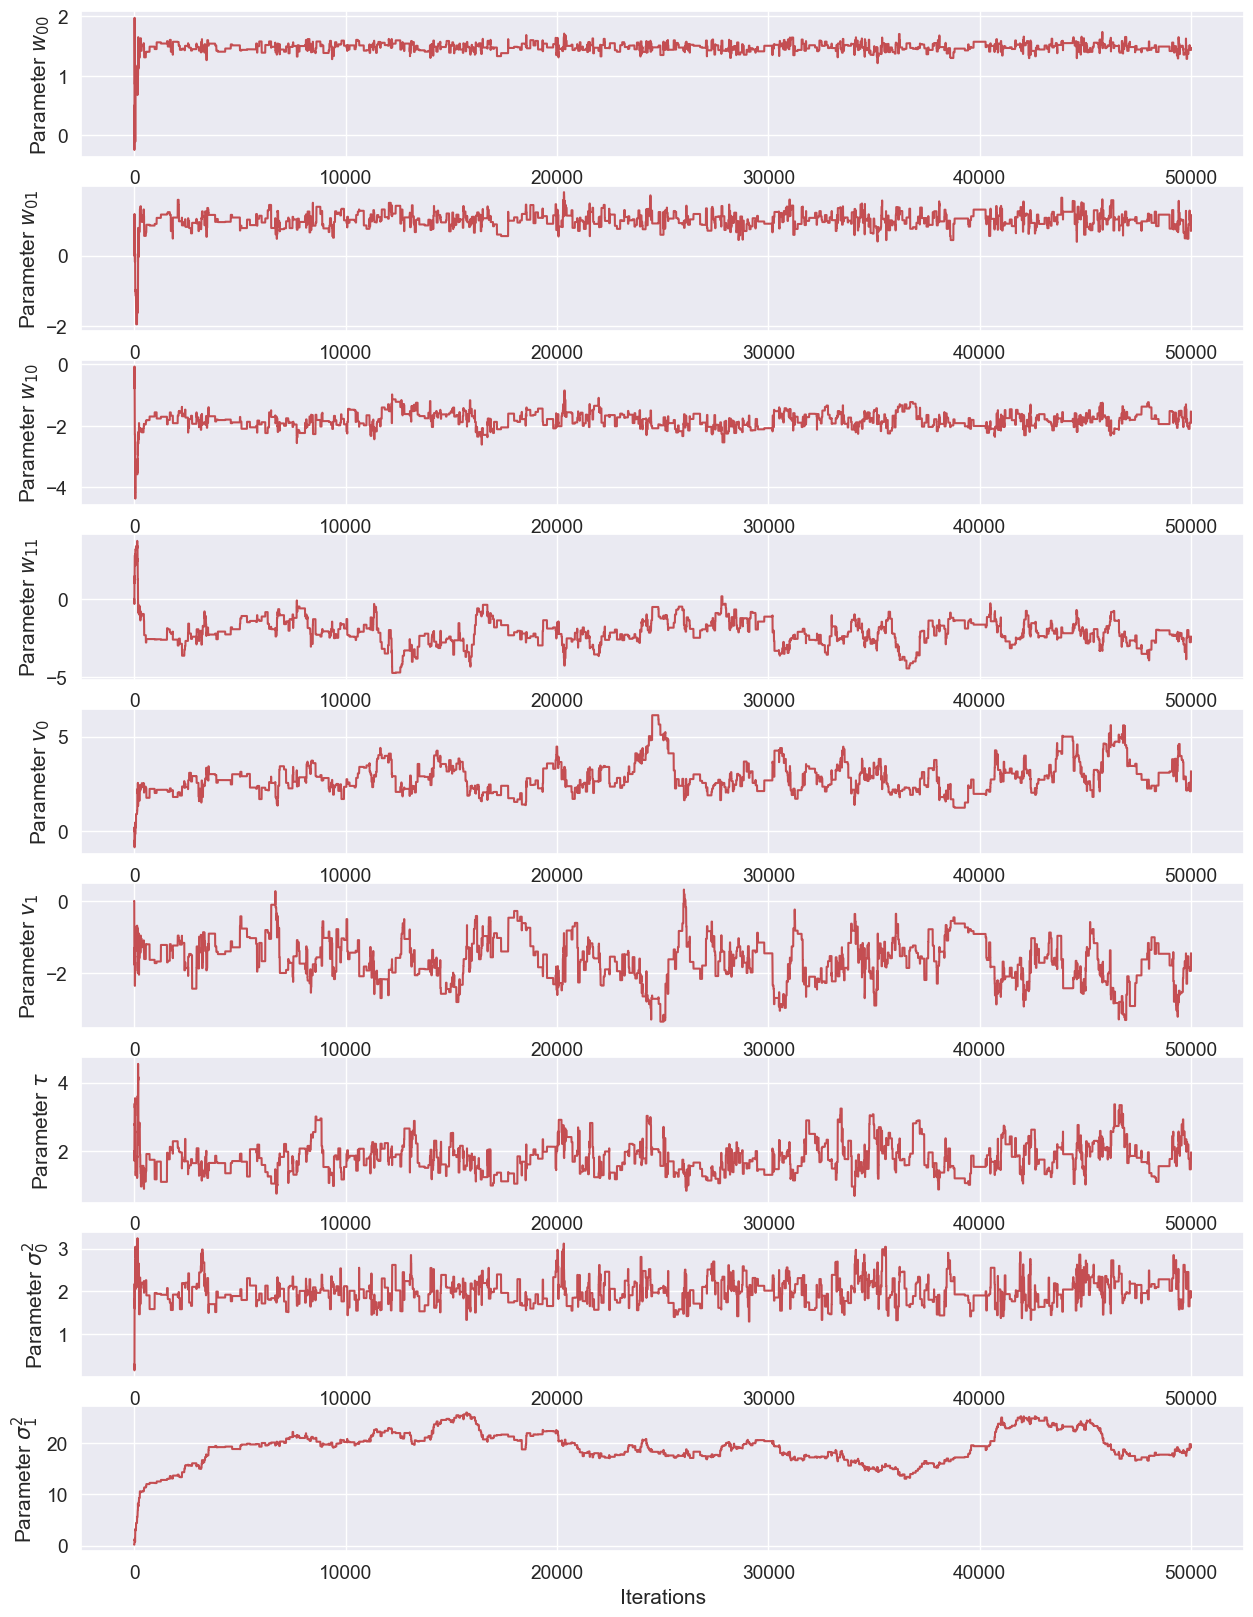

In [72]:
name_params = ['$w_{00}$', '$w_{01}$', '$w_{10}$', '$w_{11}$', '$v_0$', '$v_1$', '$\\tau$', '$\\sigma^2_0$', '$\\sigma^2_1$']
fig, axes = plt.subplots(num_params, 1, figsize=(15, 20))

for i in range(num_params):
    axes[i].plot(thetas[:, i], 'r-')
    axes[i].set(ylabel=f'Parameter {name_params[i]}')
axes[-1].set_xlabel('Iterations')

In [73]:
# get rid of warm-up samples
warm_up = int(0.2*num_iter)
thetas = thetas[warm_up:, :]

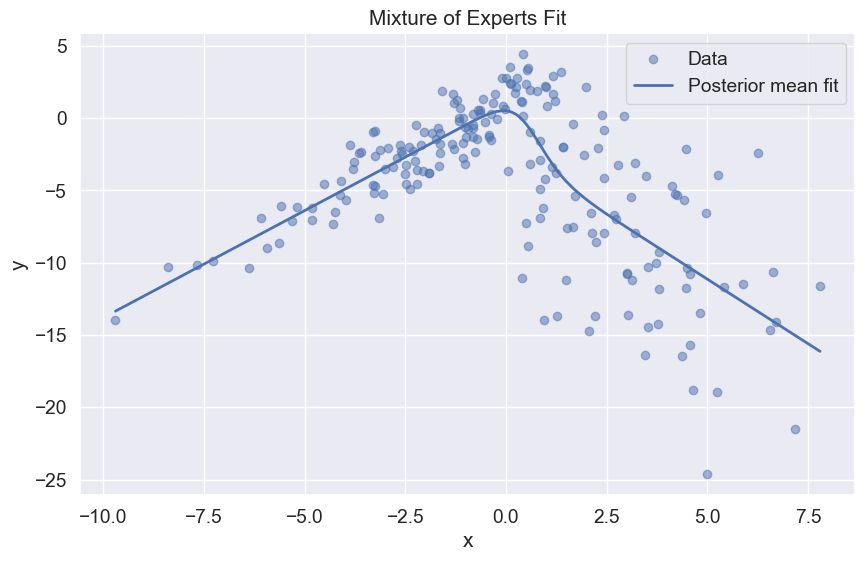

In [74]:
# Compute posterior means
w0s = thetas[:, :2]
w1s = thetas[:, 2:4]
vs = thetas[:, 4:6]
taus = thetas[:, 6]
sig02s = thetas[:, 7]
sig12s = thetas[:, 8]

w0_mean = jnp.mean(w0s,axis=0)
w1_mean = jnp.mean(w1s,axis=0)
v_mean = jnp.mean(vs,axis=0)
tau_mean = jnp.mean(taus)
sig02_mean = jnp.mean(sig02s)
sig12_mean = jnp.mean(sig12s)

# Make predictions with posterior means
pi = sigmoid(v_mean @ xt.T)  # gating probabilities
y_pred = (1 - pi) * (w0_mean @ xt.T) + pi * (w1_mean @ xt.T)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, label='Data')
pairs = sorted(zip(x.tolist(), y_pred.tolist()))
c, d = zip(*pairs)
plt.plot(c, d, linewidth=2, label='Posterior mean fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Mixture of Experts Fit')
plt.show()

> Task 1.4: Report the posterior mean and 95\% credibility intervals for all parameters

In [75]:
print(f'The mean of w0 is {w0_mean}, and the 95% credibility interval is {jnp.percentile(w0s, jnp.array([2.5, 97.5]),axis=0)}')
print(f'The mean of w1 is {w1_mean}, and the 95% credibility interval is {jnp.percentile(w1s, jnp.array([2.5, 97.5]),axis=0)}')
print(f'The mean of v is {v_mean}, and the 95% credibility interval is {jnp.percentile(vs, jnp.array([2.5, 97.5]),axis=0)}')
print(f'The mean of sigma0 is {sig02_mean}, and the 95% credibility interval is {jnp.percentile(sig02s, jnp.array([2.5, 97.5]))}')
print(f'The mean of sigma1 is {sig12_mean}, and the 95% credibility interval is {jnp.percentile(sig12s, jnp.array([2.5, 97.5]))}')

The mean of w0 is [1.4820572 1.0194222], and the 95% credibility interval is [[1.350195   0.58937055]
 [1.6018561  1.4121455 ]]
The mean of w1 is [-1.7851212 -2.211881 ], and the 95% credibility interval is [[-2.2420526  -4.0114503 ]
 [-1.28722    -0.60893583]]
The mean of v is [ 2.927923  -1.6853378], and the 95% credibility interval is [[ 1.5506487  -2.8837967 ]
 [ 4.994941   -0.52565944]]
The mean of sigma0 is 2.002276659011841, and the 95% credibility interval is [1.4604177 2.6259835]
The mean of sigma1 is 19.562511444091797, and the 95% credibility interval is [14.638479 24.96649 ]


> Task 1.5: For $x\in[-12,12]$, plot the posterior predictive distribution for $p(\pi^{*}|y,x^{*})$, $p(y^{*}|y,x^{*},z^{*}=0)$ and $p(y^{*}|y,x,z^{*}=1)$ on top of the data

In [76]:
def plot_summary(ax, x, s, interval=95, num_samples=100, sample_color='k', sample_alpha=0.4, interval_alpha=0.25, color='r', legend=True, title="", plot_mean=True, plot_median=False, label="", seed=0):
    
    b = 0.5*(100 - interval)
    
    lower = np.percentile(s, b, axis=0).T
    upper = np.percentile(s, 100-b, axis=0).T
    
    if plot_median:
        median = np.percentile(s, [50], axis=0).T
        lab = 'Median'
        if len(label) > 0:
            lab += " %s" % label
        ax.plot(x.ravel(), median, label=lab, color=color, linewidth=4)
        
    if plot_mean:
        mean = np.mean(s, axis=0).T
        lab = 'Mean'
        if len(label) > 0:
            lab += " %s" % label
        ax.plot(x.ravel(), mean, '--', label=lab, color=color, linewidth=4)
    ax.fill_between(x.ravel(), lower.ravel(), upper.ravel(), color=color, alpha=interval_alpha, label='%d%% Interval' % interval)    
    
    if num_samples > 0:
        np.random.seed(seed)
        idx_samples = np.random.choice(range(len(s)), size=num_samples, replace=False)
        ax.plot(x, s[idx_samples, :].T, color=sample_color, alpha=sample_alpha);
    
    if legend:
        ax.legend(loc='best')
        
    if len(title) > 0:
        ax.title(title, fontweight='bold')
        
def plot_predictions(ax, x, s, num_samples=100, sample_color='k', sample_alpha=0.4, color='r', legend=False, plot_median=False, plot_mean=True, seed=123, title=''):

    plot_summary(ax, x, s, color=color, interval=99, num_samples=0, interval_alpha=0.25, plot_mean=False, plot_median=False, legend=legend, seed=seed)
    plot_summary(ax, x, s, color=color, interval=95, num_samples=0, sample_alpha=0.1, interval_alpha=0.35, plot_mean=False, plot_median=False, legend=legend, seed=seed)
    plot_summary(ax, x, s, color=color, interval=75, interval_alpha=0.6, num_samples=num_samples, sample_alpha=sample_alpha, plot_mean=False, plot_median=False, legend=legend, seed=seed, sample_color=sample_color)
    
    if plot_median:
        median = np.percentile(s, [50], axis=0).T
        ax.plot(x.ravel(), median, label='Median', color='k', linewidth=4, alpha=0.7)
        
    if plot_mean:
        mean = np.mean(s, axis=0).T
        ax.plot(x.ravel(), mean, '-', label='Mean', color='k', linewidth=4, alpha=0.7)
        
    if title:
        ax.set_title(title, fontweight='bold')

    if legend:
        ax.legend(loc='best')

[Text(0.5, 1.0, '$p(y^*|y, x^*, z^*=1)$ (Expert 1)'),
 Text(0.5, 0, 'x'),
 Text(0, 0.5, '$f_1$')]

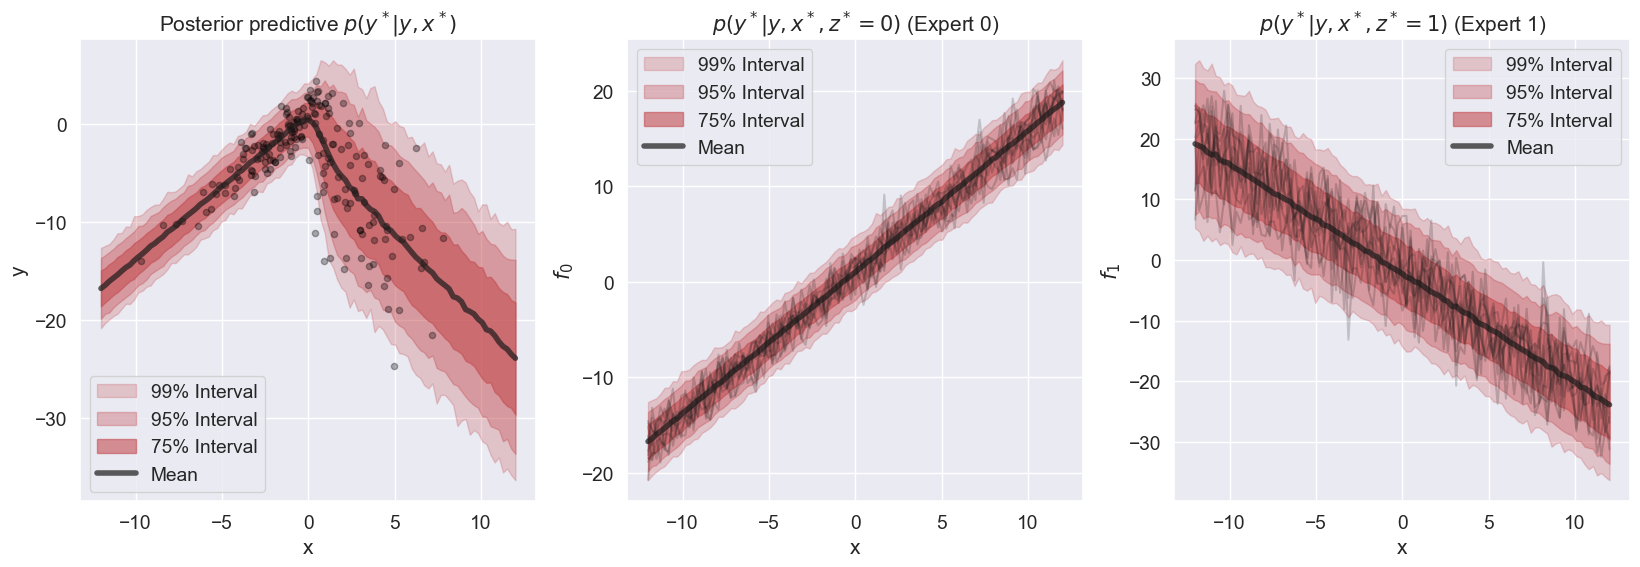

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Define prediction range
x_pred = jnp.linspace(-12, 12, 101)
x_pred_aug = jnp.vstack((x_pred, jnp.ones_like(x_pred))).T

# Store samples
pi_samples, y0_samples, y1_samples = [], [], []

warm_up = int(0.5 * num_iter)
thin = 10

key = random.PRNGKey(1)
for theta_i in thetas[warm_up::thin]:
    key, key0, key1 = random.split(key, 3)
    
    # Extract parameters
    w0 = theta_i[:2]
    w1 = theta_i[2:4]
    v = theta_i[4:6]
    sig02 = theta_i[7]
    sig12 = theta_i[8]
    
    # Compute gating probability and predictions
    pi = sigmoid(v @ x_pred_aug.T)
    f0 = w0 @ x_pred_aug.T
    f1 = w1 @ x_pred_aug.T
    
    # Sample from each expert
    y0 = f0 + jnp.sqrt(sig02) * random.normal(key0, shape=f0.shape)
    y1 = f1 + jnp.sqrt(sig12) * random.normal(key1, shape=f1.shape)
    
    pi_samples.append(pi)
    y0_samples.append(y0)
    y1_samples.append(y1)

# Convert to arrays
pi_samples = jnp.array(pi_samples)
y0_samples = jnp.array(y0_samples)
y1_samples = jnp.array(y1_samples)

# Compute mixture of predictions
y_mix_samples = pi_samples * y1_samples + (1 - pi_samples) * y0_samples

plot_predictions(ax[0], x_pred, y_mix_samples, num_samples=0, legend=True, sample_alpha=.2)
plot_predictions(ax[1], x_pred, y0_samples, num_samples=10, legend=True, sample_alpha=.2)
plot_predictions(ax[2], x_pred, y1_samples, num_samples=10, legend=True, sample_alpha=.2)

ax[0].scatter(x, y, alpha=0.3, s=20, color='black')
ax[0].set(title='Posterior predictive $p(y^*|y, x^*)$', xlabel='x', ylabel='y')
ax[1].set(title='$p(y^*|y, x^*, z^*=0)$ (Expert 0)', xlabel='x', ylabel='$f_0$')
ax[2].set(title='$p(y^*|y, x^*, z^*=1)$ (Expert 1)', xlabel='x', ylabel='$f_1$')

> Task 1.6: For $x\in[-12,12]$, plot posterior predictive distribution for $p(y^{*}|y,x^{*})$